# Modelo 1

In [1]:
%cd ..

c:\Users\juanw\Desktop\garbage-classification


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report,accuracy_score
import os

## Carga de Datos 

In [4]:
from src.carga import cargar_datos

In [5]:
root = 'data/Garbage-classification/Garbage-classification/'
df = cargar_datos(root)
df.head()

,x,y
1398,data/Garbage-classification/Garbage-classifica...,paper
680,data/Garbage-classification/Garbage-classifica...,glass
1423,data/Garbage-classification/Garbage-classifica...,paper
1650,data/Garbage-classification/Garbage-classifica...,paper
2129,data/Garbage-classification/Garbage-classifica...,plastic


## Carga de datos en Colab

In [ ]:
import kagglehub

# Descargar dataset
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification", path="data/")

print(f"📦 Dataset descargado en: {path}")

In [ ]:
import pandas as pd
import os

def cargar_datos_colab(ruta_archivo):
    data = {}

    for i in os.listdir(ruta_archivo):
      if i == 'Garbage classification':
        ruta_clase = os.path.join(ruta_archivo,i)
        if os.path.isdir(ruta_clase):
            for ruta_actual, subcarpetas, archivos in os.walk(ruta_clase):
                for k in archivos:
                    data[os.path.join(ruta_actual, k)] = os.path.basename(ruta_actual) 

    df = pd.DataFrame(data.items(), columns=['x', 'y'])
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    return df

In [ ]:
df = cargar_datos_colab(path)

## Division de los datos 

In [6]:
from sklearn.model_selection import train_test_split

# 80% train, 20% (test + validación)
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['y']
 )

# Del 20% (test + validacion): 10% validación y 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['y']
 )

print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Validación: {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test: {len(test_df)} ({len(test_df)/len(df):.1%})")

Train: 2021 (80.0%)
Validación: 253 (10.0%)
Test: 253 (10.0%)


## Modificacion de las imagenes y carga en memoria.

In [7]:
def load_images(df, size):
    images = []
    labels = []
    
    for _, row in df.iterrows():
        ruta = row['x']
        label = row['y']
        
        img = cv2.imread(ruta)                  
        img = cv2.resize(img, (size, size))    
        img = img.astype('float32') / 255.0    
        
        images.append(img)
        labels.append(label)
    
    X = np.array(images)
    y = np.array(labels)
    
    return X, y

In [8]:
x_train, y_train = load_images(train_df, size=128)
x_val, y_val = load_images(val_df, size=128)
x_test, y_test = load_images(test_df, size=128)

In [9]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((2021, 128, 128, 3),
 (2021,),
 (253, 128, 128, 3),
 (253,),
 (253, 128, 128, 3),
 (253,))

Encoder para los labels

In [10]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val  = le.transform(y_val)
y_test  = le.transform(y_test)

In [11]:
le.classes_

array(['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'],
      dtype='<U9')

## Aplicacion del modelo

In [14]:
from src.modelo1 import estructura_modelo
from src.modelo_simple import compilar
from src.curvas import graf_pedida,graf_acc,plot_confusion

In [32]:
modelo,resumen=estructura_modelo(input_shape=(128, 128, 3), num_classes=len(le.classes_))
print(resumen)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,094 (4.27 KB)

 Trainable params: 1,094 (4.27 KB)

 Non-trainable params: 0 (0.00 B)

None


In [33]:
modelo=compilar(modelo,learning_rate=0.01)

In [34]:
hist = modelo.fit(x_train,y_train,validation_data=(x_val, y_val),batch_size=128,epochs=200)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - loss: 1.7413 - sparse_categorical_accuracy: 0.2128 - val_loss: 1.7209 - val_sparse_categorical_accuracy: 0.1976
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - loss: 1.7190 - sparse_categorical_accuracy: 0.2177 - val_loss: 1.7064 - val_sparse_categorical_accuracy: 0.2372
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - loss: 1.7067 - sparse_categorical_accuracy: 0.2197 - val_loss: 1.6908 - val_sparse_categorical_accuracy: 0.2569
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - loss: 1.6887 - sparse_categorical_accuracy: 0.2474 - val_loss: 1.6596 - val_sparse_categorical_accuracy: 0.3004
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - loss: 1.6663 - sparse_categorical_accuracy: 0.2909 - val_loss: 1.6220 - val_sparse_categorical_accuracy: 0.3913
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 243ms/step - loss: 1.6389 - sparse_categorical_accuracy: 0.3107 - val_loss: 1.5933 - val_sparse_categorical_accuracy: 0.312

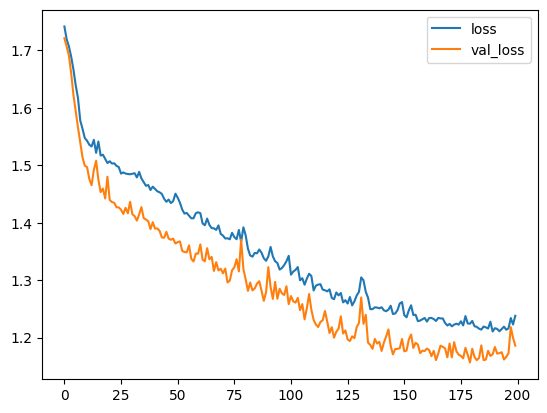

None


In [35]:
grafico = graf_pedida(hist)
print(grafico)

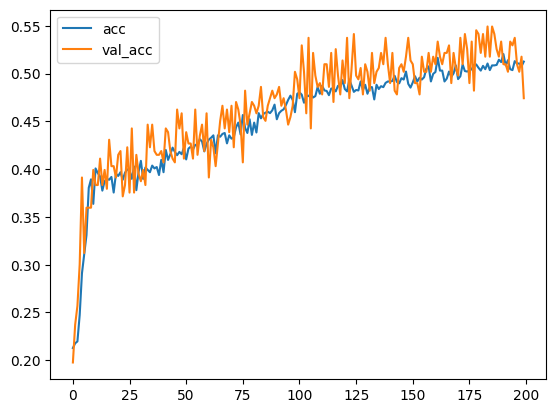

None


In [36]:
grafico2 = graf_acc(hist)
print(grafico2)

### Evaluamos el modelo

In [20]:
score1 = modelo.evaluate(x_train, y_train, steps=100)
print(score1)

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3649 - sparse_categorical_accuracy: 0.4631
[1.36493718624115, 0.46313706040382385]


In [21]:
score2 = modelo.evaluate(x_val, y_val, steps=100)
print(score2)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3103 - sparse_categorical_accuracy: 0.4506
[1.3102786540985107, 0.45059287548065186]


In [22]:
score3 = modelo.evaluate(x_test, y_test, steps=100)
print(score3)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3958 - sparse_categorical_accuracy: 0.4545
[1.3958364725112915, 0.4545454680919647]


### Matrices de confusion

In [23]:
y_train_pred = modelo.predict(x_train)
y_train_pred = y_train_pred.argmax(axis=1)

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [24]:
y_val_pred = modelo.predict(x_val)
y_val_pred = y_val_pred.argmax(axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [25]:
y_test_pred = modelo.predict(x_test)
y_test_pred = y_test_pred.argmax(axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


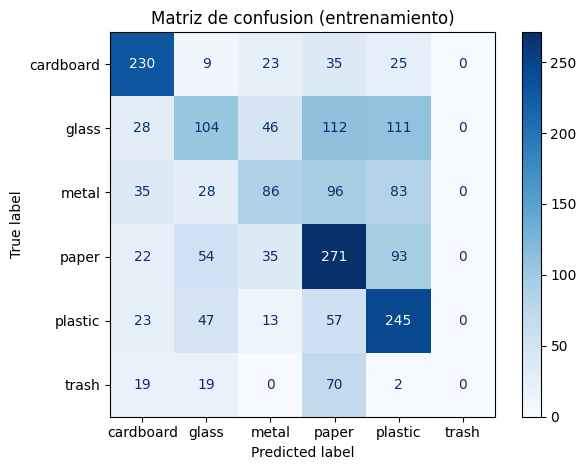

In [26]:
plot_confusion(y_train, y_train_pred, le.classes_, title='Matriz de confusion (entrenamiento)')

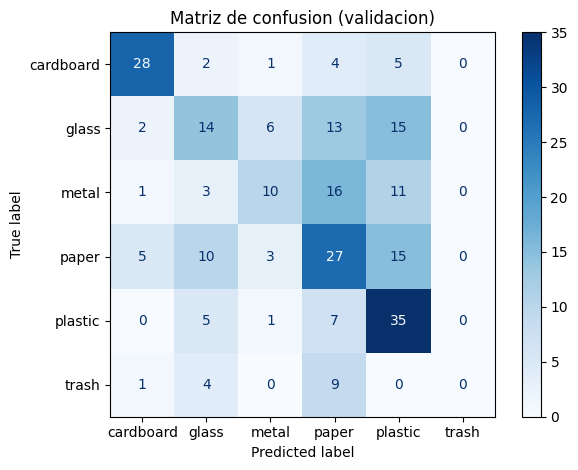

In [27]:
plot_confusion(y_val, y_val_pred, le.classes_, title='Matriz de confusion (validacion)')

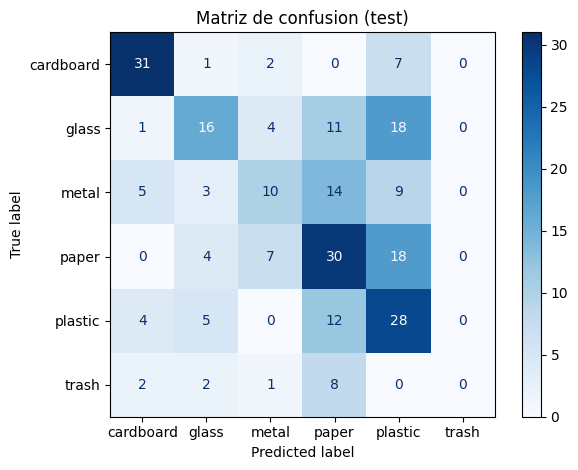

In [28]:
plot_confusion(y_test, y_test_pred, le.classes_, title='Matriz de confusion (test)')

### Más metricas

In [29]:
print("Classification Report - Train:")
print(classification_report(y_train, y_train_pred, target_names=le.classes_))

Classification Report - Train:
              precision    recall  f1-score   support

   cardboard       0.64      0.71      0.68       322
       glass       0.40      0.26      0.31       401
       metal       0.42      0.26      0.32       328
       paper       0.42      0.57      0.49       475
     plastic       0.44      0.64      0.52       385
       trash       0.00      0.00      0.00       110

    accuracy                           0.46      2021
   macro avg       0.39      0.41      0.39      2021
weighted avg       0.43      0.46      0.44      2021



In [30]:
print("Classification Report - validacion:")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

Classification Report - validacion:
              precision    recall  f1-score   support

   cardboard       0.76      0.70      0.73        40
       glass       0.37      0.28      0.32        50
       metal       0.48      0.24      0.32        41
       paper       0.36      0.45      0.40        60
     plastic       0.43      0.73      0.54        48
       trash       0.00      0.00      0.00        14

    accuracy                           0.45       253
   macro avg       0.40      0.40      0.38       253
weighted avg       0.44      0.45      0.43       253



In [31]:
print("Classification Report - test:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

Classification Report - test:
              precision    recall  f1-score   support

   cardboard       0.72      0.76      0.74        41
       glass       0.52      0.32      0.40        50
       metal       0.42      0.24      0.31        41
       paper       0.40      0.51      0.45        59
     plastic       0.35      0.57      0.43        49
       trash       0.00      0.00      0.00        13

    accuracy                           0.45       253
   macro avg       0.40      0.40      0.39       253
weighted avg       0.45      0.45      0.44       253

